# Fingerprint Gender Classification

**Dataset:** Sokoto Coventry Fingerprint Dataset (SOCOFing)
**Source:** [Kaggle — ruizgara/socofing](https://www.kaggle.com/datasets/ruizgara/socofing)

Submitted by: Abdullah Basit


**Part 1:** Dataset Selection & Data Preprocessing (Steps 1-9)

**Part 2**: Feature Engineering & Exploratory Data Analysis (Steps 10-12)



## **Part 1**
## Step 1: Importing libraries

In [ ]:
import os                                    # lets Python work with file paths and folders on the computer
import glob                                  # finds all files that match a pattern, e.g. every ".BMP" file in a folder
import numpy as np                           # used for working with arrays of numbers (our images become number arrays)
import pandas as pd                          # used for building and working with data tables (like an Excel sheet in code)
import matplotlib.pyplot as plt              # used for drawing charts and graphs
import seaborn as sns                        # built on top of matplotlib, makes nicer-looking statistical charts
import cv2                                   # OpenCV library, used to load images and process them (resize, grayscale, edges)
from PIL import Image                        # another way to open and preview images, used for quick visual checks
from sklearn.model_selection import train_test_split      # splits data into training/validation/testing groups
from sklearn.preprocessing import LabelEncoder             # converts text labels like "M"/"F" into numbers like 0/1
from sklearn.feature_selection import (                     # tools to figure out which features actually matter
    VarianceThreshold, mutual_info_classif, SelectKBest, f_classif
)
from sklearn.ensemble import RandomForestClassifier         # a machine learning model, used here just to rank feature importance
from imblearn.combine import SMOTETomek                     # fixes class imbalance (unequal number of male/female samples)

sns.set_style("whitegrid")                   # sets a clean, light grid background style for all seaborn plots
print("Libraries loaded.")                   # simple message to confirm everything imported correctly


Libraries loaded.


## Step 2: Download the dataset


In [ ]:
import kagglehub
dataset_path = kagglehub.dataset_download("ruizgara/socofing")   # downloads SOCOFing and returns the folder path where it was saved
print("Downloaded to:", dataset_path)

# We only need the folder with the original, unaltered fingerprints.
# SOCOFing also has an "Altered" folder for a different research task, but we don't need it, so we ignore it.
real_dir = glob.glob(os.path.join(dataset_path, "**", "Real"), recursive=True)[0]
# os.path.join(...) builds a search path pattern; "**" means "search inside all subfolders"
# glob.glob(...) returns every folder path matching "Real"; recursive=True lets it look inside nested folders
# [0] takes the first (and only) match found

image_paths = glob.glob(os.path.join(real_dir, "*.BMP"))  # gets the full path of every .BMP fingerprint image inside that folder
print("Total images found:", len(image_paths))            # len(...) counts how many image paths we collected
print("Example filename:", os.path.basename(image_paths[0]))  # os.path.basename gets just the filename, not the whole path, for the first image


Using Colab cache for faster access to the 'socofing' dataset.
Downloaded to: /kaggle/input/socofing
Total images found: 6000
Example filename: 171__M_Left_little_finger.BMP


## Step 3: Build a table of labels

Each filename already tells us the gender, hand, and finger, e.g. `1__M_Left_index_finger.BMP` means Male, Left hand, index finger.
We split the filename apart to pull out these labels.


In [ ]:
def parse_filename(path):
    filename = os.path.basename(path)           # strips the path down to just the filename, e.g. "1__M_Left_index_finger.BMP"
    subject_id, rest = filename.replace(".BMP", "").split("__")
    # .replace(".BMP", "") removes the file extension first
    # .split("__") breaks the filename at the double underscore into ["1", "M_Left_index_finger"]
    # this line unpacks that into subject_id="1" and rest="M_Left_index_finger"

    parts = rest.split("_")                      # breaks "M_Left_index_finger" into ["M", "Left", "index", "finger"]
    gender = parts[0]                            # first piece is the gender: "M" or "F"
    hand = parts[1]                              # second piece is the hand: "Left" or "Right"
    finger = "_".join(parts[2:])                 # remaining pieces joined back together: "index_finger"
    return subject_id, gender, hand, finger       # send all four pieces back

data = []                                        # empty list that will hold one row (dictionary) per image
for path in image_paths:                         # loop through every image path we found earlier
    subject_id, gender, hand, finger = parse_filename(path)   # extract all labels from this image's filename
    data.append({                                # add a new row to our list
        "filepath": path,
        "subject_id": subject_id,
        "gender": gender,
        "hand": hand,
        "finger": finger,
    })

df = pd.DataFrame(data)                          # convert the list of rows into a proper pandas table (DataFrame)
print("Dataset shape (rows, columns):", df.shape)   # .shape tells us (number of images, number of columns) - a quick size check
df.head()                                        # .head() previews the first 5 rows of the table


Dataset shape (rows, columns): (6000, 5)


,filepath,subject_id,gender,hand,finger
0,/kaggle/input/socofing/SOCOFing/Real/171__M_Le...,171,M,Left,little_finger
1,/kaggle/input/socofing/SOCOFing/Real/463__F_Ri...,463,F,Right,ring_finger
2,/kaggle/input/socofing/SOCOFing/Real/470__F_Ri...,470,F,Right,ring_finger
3,/kaggle/input/socofing/SOCOFing/Real/367__M_Le...,367,M,Left,index_finger
4,/kaggle/input/socofing/SOCOFing/Real/446__M_Ri...,446,M,Right,index_finger


## Step 4: Understand the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   filepath    6000 non-null   object
 1   subject_id  6000 non-null   object
 2   gender      6000 non-null   object
 3   hand        6000 non-null   object
 4   finger      6000 non-null   object
dtypes: object(5)
memory usage: 234.5+ KB
gender
M    4770
F    1230
Name: count, dtype: int64


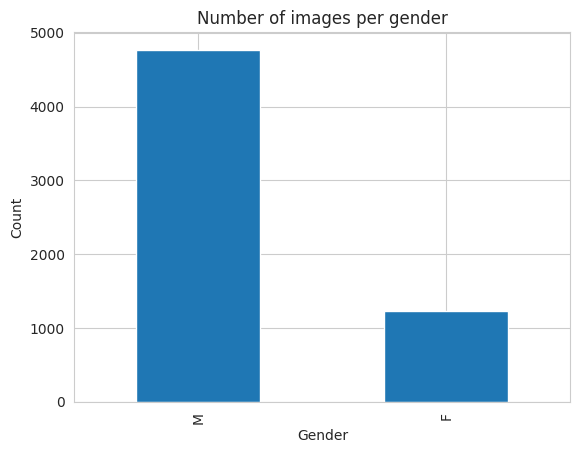

Missing values:
 filepath      0
subject_id    0
gender        0
hand          0
finger        0
dtype: int64
Duplicate rows: 0


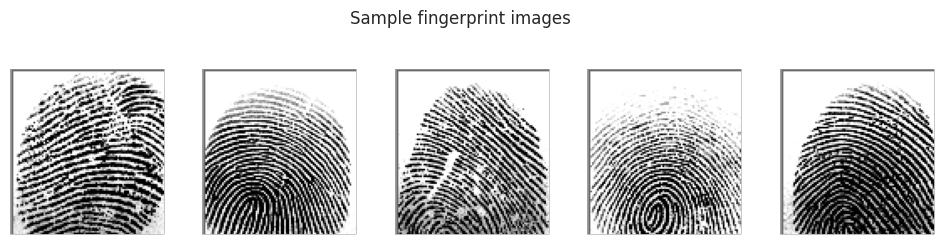

Image size: (96, 103) | Mode: RGBA


In [ ]:
# Column data types
df.info()
# .info() prints each column's name, how many non-empty values it has, and its data type (e.g. text/object)

# How many images per gender? (this is our target variable, the thing we want to predict)
print(df["gender"].value_counts())
# .value_counts() counts how many times each unique value ("M", "F") appears in the gender column

df["gender"].value_counts().plot(kind="bar", title="Number of images per gender")
# turns that count into a simple bar chart
plt.xlabel("Gender")                            # labels the x-axis
plt.ylabel("Count")                             # labels the y-axis
plt.show()                                      # actually displays the chart

# Check for missing values
print("Missing values:\n", df.isna().sum())
# .isna() marks every empty/missing cell as True; .sum() adds those up per column, so we see how many are missing

# Check for duplicate rows (same filepath listed twice)
print("Duplicate rows:", df.duplicated().sum())
# .duplicated() flags rows that are exact copies of an earlier row; .sum() counts how many such duplicates exist

# Look at a few example fingerprint images
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
# creates a figure with 1 row and 5 side-by-side plot slots ("axes"), sized 12x3 inches

for ax, path in zip(axes, df["filepath"].sample(5, random_state=1)):
    # df["filepath"].sample(5) picks 5 random image paths; random_state=1 makes the "random" choice repeatable
    # zip(axes, ...) pairs each plot slot with one of those 5 image paths
    img = Image.open(path)                      # opens the image file
    ax.imshow(img, cmap="gray")                 # displays it in that plot slot, using a grayscale color map
    ax.axis("off")                              # hides the x/y axis ticks/numbers since they're meaningless for an image

plt.suptitle("Sample fingerprint images")       # adds one overall title above all 5 images
plt.show()                                      # displays the figure

# Check the size of one image
sample_img = Image.open(df["filepath"].iloc[0])  # .iloc[0] grabs the filepath of the very first row in the table
print("Image size:", sample_img.size, "| Mode:", sample_img.mode)
# .size gives (width, height) in pixels; .mode tells us the color format (e.g. "L" for grayscale, "RGBA" for color+transparency)





## Step 5: Preprocess the images

For every image we will:
1. Resize it to a fixed size (96x96) so all images are the same shape
2. Convert it to grayscale (fingerprints are already grayscale, but we make sure)
3. Scale pixel values from 0-255 down to 0-1 (this helps the model train faster later)


In [ ]:
IMG_SIZE = 96   # every image will be resized to 96x96 pixels, so all images have the same, consistent shape

def preprocess_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)   # loads the image from disk as a single-channel grayscale image
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))     # resizes it to exactly 96x96 pixels, no matter its original size
    img = img.astype("float32") / 255.0             # converts pixel values (originally 0-255 integers) into 0-1 decimals
    return img                                      # sends back the cleaned-up image

# Quick test on one image
test_img = preprocess_image(df["filepath"].iloc[0])   # run the function on the first image, just to check it works
print("Processed image shape:", test_img.shape)       # should print (96, 96)
print("Pixel value range:", test_img.min(), "to", test_img.max())   # should print something like 0.0 to 1.0

# Now process every image in the dataset and stack them into one array
X = np.array([preprocess_image(p) for p in df["filepath"]])
# this loops through every filepath, preprocesses it, and stacks all the resulting images into one big array

X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
# reshape adds an extra "channel" dimension at the end (needed because CNNs expect images in [height, width, channels] form)
# -1 tells numpy "figure out this dimension automatically" (it will be the number of images, 6000)

print("Final image data shape:", X.shape)   # should print (6000, 96, 96, 1)


Processed image shape: (96, 96)
Pixel value range: 0.0 to 1.0
Final image data shape: (6000, 96, 96, 1)


## Step 6: Encode the target label

Machine learning models need numbers, not letters. We convert "M"/"F" into 0/1.


In [ ]:
encoder = LabelEncoder()                     # creates a LabelEncoder object, which will learn the M/F -> 0/1 mapping
y = encoder.fit_transform(df["gender"])      # .fit_transform learns the mapping AND immediately converts the column to numbers

print("Label mapping:", dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))
# encoder.classes_ lists the original labels it found (alphabetically: "F", "M")
# encoder.transform(...) converts those same labels to their number codes
# zip(...) pairs each original label with its number code, and dict(...) turns that into an easy-to-read dictionary


Label mapping: {'F': np.int64(0), 'M': np.int64(1)}


## Step 7: Split into train / validation / test sets

- Train: used to train the model
- Validation used to tune the model while training
- Test used only at the very end, to check final performance

We use stratify=y so each split keeps the same male/female ratio as the full dataset.


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
# splits the full data into 70% (train) and 30% (temp)
# test_size=0.30 means 30% goes to "temp"; stratify=y keeps the M/F ratio the same in both parts
# random_state=42 makes the split reproducible (same result every time we run it)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)
# splits that remaining 30% ("temp") in half: 15% becomes validation, 15% becomes test

print("Train:", X_train.shape[0], "images")       # .shape[0] gives the number of images in that set
print("Validation:", X_val.shape[0], "images")
print("Test:", X_test.shape[0], "images")


Train: 4200 images
Validation: 900 images
Test: 900 images


## Step 8: Handle class imbalance (SMOTE-Tomek)

SOCOFing has more male fingerprints than female ones. If we train on this, the model may just learn to guess "male" most of the time. SMOTE-Tomek fixes this by creating new synthetic minority-class samples and removing borderline/noisy points, so both classes end up balanced.

Important we only balance the training set. The validation and test sets stay untouched, because they need to represent the real world.


In [ ]:
print("Before balancing:", np.bincount(y_train))
# np.bincount counts how many 0s and 1s (female/male) are currently in the training labels

# SMOTE-Tomek needs flat (non-image-shaped) data, so we temporarily flatten each image
X_train_flat = X_train.reshape(X_train.shape[0], -1)
# reshape(num_images, -1) turns each 96x96x1 image into one long row of 9216 numbers

smote_tomek = SMOTETomek(random_state=42)    # creates the SMOTE-Tomek balancer, random_state=42 makes it reproducible
X_train_flat_balanced, y_train_balanced = smote_tomek.fit_resample(X_train_flat, y_train)
# .fit_resample looks at the flattened data + labels, adds synthetic minority samples, removes noisy overlapping pairs,
# and returns the new, balanced dataset

# Reshape back into images
X_train_balanced = X_train_flat_balanced.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
# turns the flat rows back into proper 96x96x1 image shape

print("After balancing:", np.bincount(y_train_balanced))


Before balancing: [ 861 3339]
After balancing: [3339 3339]


## Step 9: Save the preprocessed data

In [ ]:
os.makedirs("preprocessed_data", exist_ok=True)
# creates a folder called "preprocessed_data" to store our output file; exist_ok=True means don't error if it already exists

np.savez_compressed(
    "preprocessed_data/socofing_gender_preprocessed.npz",
    X_train=X_train_balanced, y_train=y_train_balanced,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
)
# saves all six arrays (train/val/test images and labels) into a single compressed .npz file,
# so we don't have to redo all this preprocessing every time - we can just load this file later

print("Saved! This file will be loaded in the next notebook to train the model.")


Saved! This file will be loaded in the next notebook to train the model.


---
# Part 2: Feature Engineering & Exploratory Data Analysis (EDA)

Our raw data so far is images. We cannot directly run correlation heatmaps, pair plots, or scatter plots on that. So this section's main job is to turn each fingerprint image into a handful of meaningful numbers (features), then explore and visualize those numbers.

**Note on non-applicable steps:** this dataset has no date/time fields and no text fields, so those parts of feature engineering aren't relevant here and are intentionally skipped (not forgotten).


## Step 10: Feature Engineering - extract numeric features from each image

We compute four simple, easy-to-understand numeric features per fingerprint image:

- mean_intensity - average brightness of the image
- std_intensity - contrast (how spread out the pixel values are)
- edge_density - proportion of pixels that are part of a ridge edge (using Canny edge detection)
- ridge_density - proportion of dark pixels (ridges are dark, background/valleys are light)


In [ ]:
def extract_features(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)   # load the image as grayscale
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))     # resize to our standard 96x96 size

    mean_intensity = img.mean()      # average of all pixel values (higher = brighter overall image)
    std_intensity = img.std()        # standard deviation of pixel values (higher = more contrast between light/dark areas)

    edges = cv2.Canny(img, threshold1=100, threshold2=200)
    # Canny is an edge-detection algorithm; it returns a black image with white pixels where it detected an edge
    # threshold1/threshold2 control how sensitive it is to what counts as an edge

    edge_density = np.sum(edges > 0) / edges.size
    # edges > 0 marks every "edge" pixel as True; np.sum counts them; dividing by edges.size (total pixels) gives a proportion

    ridge_density = np.sum(img < 128) / img.size
    # since ridges are the dark lines on a fingerprint, we count pixels darker than the midpoint (128 out of 255)
    # and divide by the total number of pixels to get the proportion of the image that is "ridge"

    return mean_intensity, std_intensity, edge_density, ridge_density   # send back all four numbers together

# Quick test on one image
print(extract_features(df["filepath"].iloc[0]))

features = df["filepath"].apply(extract_features)
# .apply runs extract_features() on every single filepath in the table, one at a time
# the result is a column where each cell is a tuple of 4 numbers (mean, std, edge, ridge)

df[["mean_intensity", "std_intensity", "edge_density", "ridge_density"]] = pd.DataFrame(
    features.tolist(), index=df.index
)
# features.tolist() converts that column of tuples into a plain list of tuples
# pd.DataFrame(...) turns that list into a small table with 4 columns
# index=df.index makes sure the rows line up correctly with our original df
# assigning it to df[[...]] adds these 4 new columns directly onto our main table

df.head()   # preview the table now that it has our new numeric feature columns



(np.float64(173.23567708333334), np.float64(100.50393862199937), np.float64(0.1804470486111111), np.float64(0.3235677083333333))


,filepath,subject_id,gender,hand,finger,mean_intensity,std_intensity,edge_density,ridge_density
0,/kaggle/input/socofing/SOCOFing/Real/171__M_Le...,171,M,Left,little_finger,173.235677,100.503939,0.180447,0.323568
1,/kaggle/input/socofing/SOCOFing/Real/463__F_Ri...,463,F,Right,ring_finger,132.687174,99.780601,0.255317,0.477214
2,/kaggle/input/socofing/SOCOFing/Real/470__F_Ri...,470,F,Right,ring_finger,149.260417,111.756532,0.192925,0.430230
3,/kaggle/input/socofing/SOCOFing/Real/367__M_Le...,367,M,Left,index_finger,154.697266,102.647570,0.223524,0.394857
4,/kaggle/input/socofing/SOCOFing/Real/446__M_Ri...,446,M,Right,index_finger,102.424371,98.679288,0.279514,0.607747


### 10.1 Encode categorical features

In [ ]:
# Encode the target (same idea as Step 6, repeated here since this section can also run on its own)
le_gender = LabelEncoder()
df["gender_encoded"] = le_gender.fit_transform(df["gender"])
print("Gender mapping:", dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))

# One-hot encode hand and finger (categorical, not ordinal - there's no natural order between fingers)
df_encoded = pd.get_dummies(df, columns=["hand", "finger"], drop_first=True)
# pd.get_dummies turns a category column (like "Left"/"Right") into separate 0/1 columns, one per category
# drop_first=True drops one category to avoid redundant columns (if it's not Left, we already know it's Right)

df_encoded.head()


Gender mapping: {'F': np.int64(0), 'M': np.int64(1)}


,filepath,subject_id,gender,mean_intensity,std_intensity,edge_density,ridge_density,gender_encoded,hand_Right,finger_little_finger,finger_middle_finger,finger_ring_finger,finger_thumb_finger
0,/kaggle/input/socofing/SOCOFing/Real/171__M_Le...,171,M,173.235677,100.503939,0.180447,0.323568,1,False,True,False,False,False
1,/kaggle/input/socofing/SOCOFing/Real/463__F_Ri...,463,F,132.687174,99.780601,0.255317,0.477214,0,True,False,False,True,False
2,/kaggle/input/socofing/SOCOFing/Real/470__F_Ri...,470,F,149.260417,111.756532,0.192925,0.430230,0,True,False,False,True,False
3,/kaggle/input/socofing/SOCOFing/Real/367__M_Le...,367,M,154.697266,102.647570,0.223524,0.394857,1,False,False,False,False,False
4,/kaggle/input/socofing/SOCOFing/Real/446__M_Ri...,446,M,102.424371,98.679288,0.279514,0.607747,1,True,False,False,False,False


## Step 11: Feature Selection

We now check which of our four engineered features are actually useful for predicting gender, and whether any are redundant.


### 11.1 Correlation between numeric features

In [ ]:
numeric_cols = ["mean_intensity", "std_intensity", "edge_density", "ridge_density"]

corr_matrix = df[numeric_cols].corr()
# .corr() computes the correlation coefficient between every pair of columns
# values range from -1 (perfectly opposite) to +1 (perfectly matching); near 0 means no relationship
corr_matrix


,mean_intensity,std_intensity,edge_density,ridge_density
mean_intensity,1.000000,-0.249066,-0.428265,-0.983749
std_intensity,-0.249066,1.000000,-0.243579,0.229731
edge_density,-0.428265,-0.243579,1.000000,0.350694
ridge_density,-0.983749,0.229731,0.350694,1.000000


### 11.2 Variance Threshold - flag near-constant features

In [ ]:
selector = VarianceThreshold(threshold=0.0)   # this will flag any feature that never changes (zero variance = useless)
selector.fit(df[numeric_cols])                 # calculates the variance (spread) of each feature column

print("Feature variances:")
for col, var in zip(numeric_cols, selector.variances_):   # loop through each feature name and its calculated variance
    print(f"  {col}: {var:.6f}")                           # print with 6 decimal places for readability

print("\nAll features kept (none have zero variance):", selector.get_support())
# .get_support() returns True/False for each feature - True means "keep it" (variance above the threshold)


Feature variances:
  mean_intensity: 182.997287
  std_intensity: 41.731730
  edge_density: 0.001183
  ridge_density: 0.009983

All features kept (none have zero variance): [ True  True  True  True]


### 11.3 Mutual Information - how much does each feature tell us about gender?

In [ ]:
mi_scores = mutual_info_classif(df[numeric_cols], df["gender_encoded"], random_state=42)
# mutual_info_classif measures how much knowing a feature's value reduces our uncertainty about the target (gender)
# higher score = more useful feature; 0 = tells us nothing about gender

mi_df = pd.DataFrame({"feature": numeric_cols, "mutual_info_score": mi_scores})
mi_df = mi_df.sort_values("mutual_info_score", ascending=False)   # sort from most useful to least useful
mi_df


,feature,mutual_info_score
2,edge_density,0.029716
1,std_intensity,0.004168
3,ridge_density,0.002430
0,mean_intensity,0.000000


### 11.4 SelectKBest - pick the top features using an ANOVA F-test

In [ ]:
selector_kbest = SelectKBest(score_func=f_classif, k="all")
# SelectKBest ranks features by statistical test score; f_classif is the ANOVA F-test, good for numeric features + a category target
# k="all" means "score every feature" rather than automatically dropping some

selector_kbest.fit(df[numeric_cols], df["gender_encoded"])   # runs the F-test between each feature and the gender target

kbest_df = pd.DataFrame({"feature": numeric_cols, "f_score": selector_kbest.scores_})
kbest_df = kbest_df.sort_values("f_score", ascending=False)   # higher F-score = stronger relationship with gender
kbest_df


,feature,f_score
2,edge_density,277.638242
0,mean_intensity,31.238758
3,ridge_density,15.909435
1,std_intensity,8.281540


## Step 12: Exploratory Data Analysis & Visualizations

### 12.1 Distribution of numerical features (Histogram / KDE)

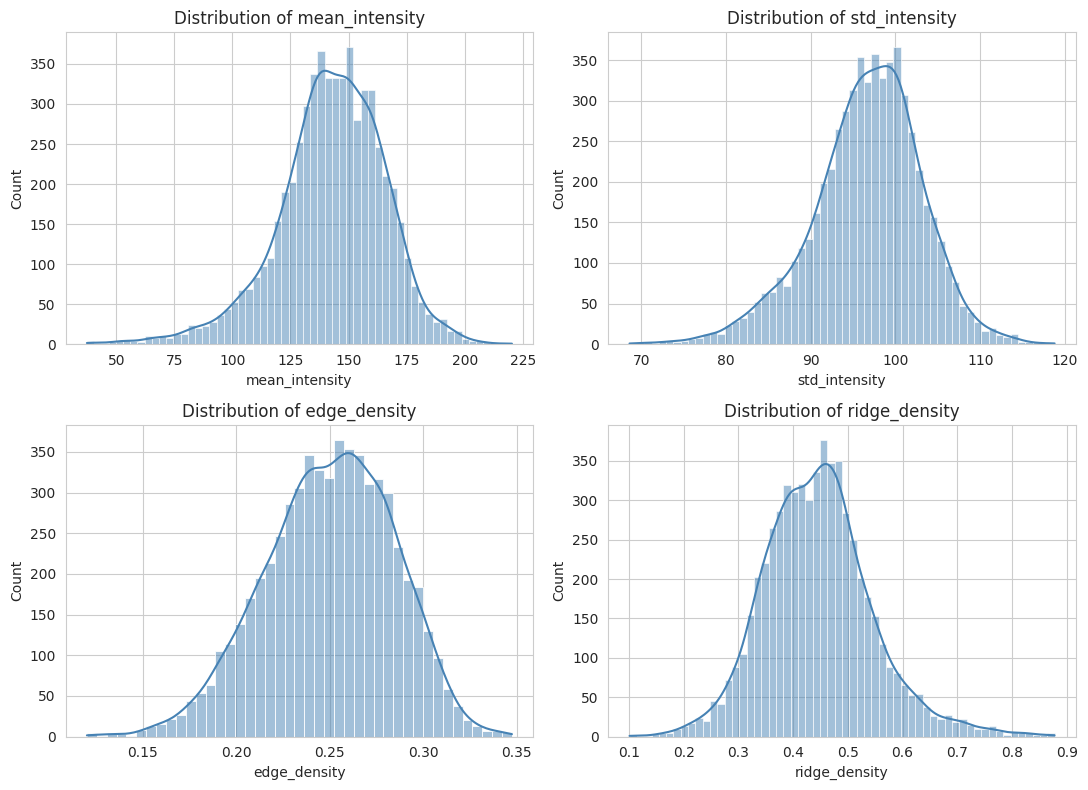

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))   # creates a 2x2 grid of plots

for ax, col in zip(axes.flatten(), numeric_cols):
    # axes.flatten() turns the 2x2 grid into a simple list of 4 plot slots, so we can loop through them one by one
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    # draws a histogram (bar-style count of values) plus a KDE line (a smoothed curve showing the same distribution)
    ax.set_title(f"Distribution of {col}")   # gives this subplot a title
    ax.set_xlabel(col)                       # labels the x-axis with the feature name
    ax.set_ylabel("Count")                   # labels the y-axis

plt.tight_layout()   # automatically adjusts spacing so titles/labels don't overlap
plt.show()


**Interpretation:** `mean_intensity` and `std_intensity` look roughly bell-shaped (normally distributed), suggesting most fingerprints have similar overall brightness/contrast. `edge_density` and `ridge_density` show how much ridge detail each image captures - any skew here suggests some images have much finer or coarser ridge patterns than others.

### 12.2 Count plots for categorical variables

/tmp/ipykernel_969/1086975602.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="gender", ax=axes[0], palette="Set2")   # bar chart counting how many rows have each gender value
/tmp/ipykernel_969/1086975602.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="hand", ax=axes[1], palette="Set2")     # same idea, but counting Left vs Right hand
/tmp/ipykernel_969/1086975602.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="finger", ax=axes[2], palette="Set2")   # y= instead of x= makes the bars hori

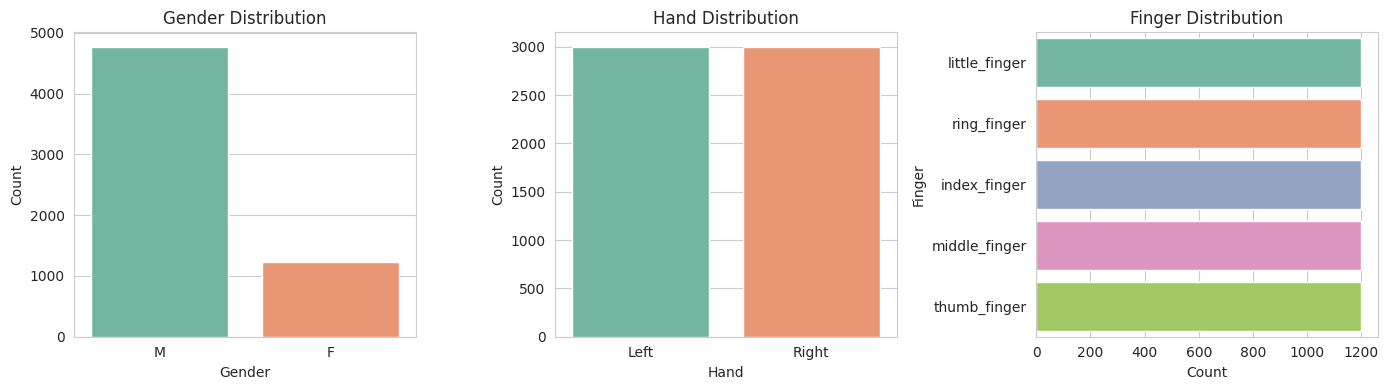

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))   # 1 row, 3 side-by-side plots

sns.countplot(data=df, x="gender", ax=axes[0], palette="Set2")   # bar chart counting how many rows have each gender value
axes[0].set_title("Gender Distribution")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Count")

sns.countplot(data=df, x="hand", ax=axes[1], palette="Set2")     # same idea, but counting Left vs Right hand
axes[1].set_title("Hand Distribution")
axes[1].set_xlabel("Hand")
axes[1].set_ylabel("Count")

sns.countplot(data=df, y="finger", ax=axes[2], palette="Set2")   # y= instead of x= makes the bars horizontal (easier to read finger names)
axes[2].set_title("Finger Distribution")
axes[2].set_xlabel("Count")
axes[2].set_ylabel("Finger")

plt.tight_layout()
plt.show()


**Interpretation:** Gender is imbalanced (more male samples which consistent with what we found in preprocessing). Hand and finger are evenly distributed, which makes sense since SOCOFing captures all 10 fingers per subject equally.

### 12.3 Target variable distribution

In [ ]:
print(df["gender"].value_counts())                              # raw counts per class
print(df["gender"].value_counts(normalize=True).round(3) * 100, "%")
# normalize=True converts counts into proportions (0 to 1) instead of raw numbers; multiplying by 100 turns it into a percentage


gender
M    4770
F    1230
Name: count, dtype: int64
gender
M    79.5
F    20.5
Name: proportion, dtype: float64 %


**Interpretation:** confirms the class imbalance already identified in the preprocessing milestone - roughly 79.5% male vs 20.5% female. This is why SMOTE-Tomek was necessary before training.

### 12.4 Box plots for outlier analysis

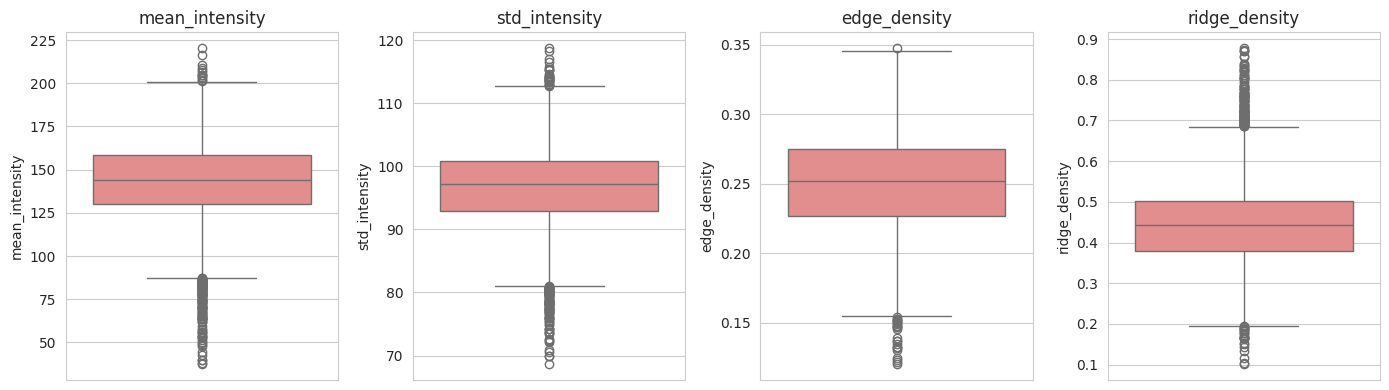

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))   # 1 row, 4 plots (one per numeric feature)

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="lightcoral")
    # a boxplot shows the median (middle line), the middle 50% of values (the box), and outliers (dots beyond the whiskers)
    ax.set_title(col)

plt.tight_layout()
plt.show()


**Interpretation:** points outside the whiskers are potential outliers - e.g. a handful of images with unusually low/high edge density might indicate blurry, smudged, or over-inked fingerprint scans. These are worth a manual look rather than automatic removal, since a genuinely unusual fingerprint isn't necessarily bad data.

### 12.5 Class-wise comparison plots (feature distributions split by gender)

/tmp/ipykernel_969/1306650963.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="gender", y=col, ax=ax, palette="Set2")
/tmp/ipykernel_969/1306650963.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="gender", y=col, ax=ax, palette="Set2")
/tmp/ipykernel_969/1306650963.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="gender", y=col, ax=ax, palette="Set2")
/tmp/ipykernel_969/1306650963.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign 

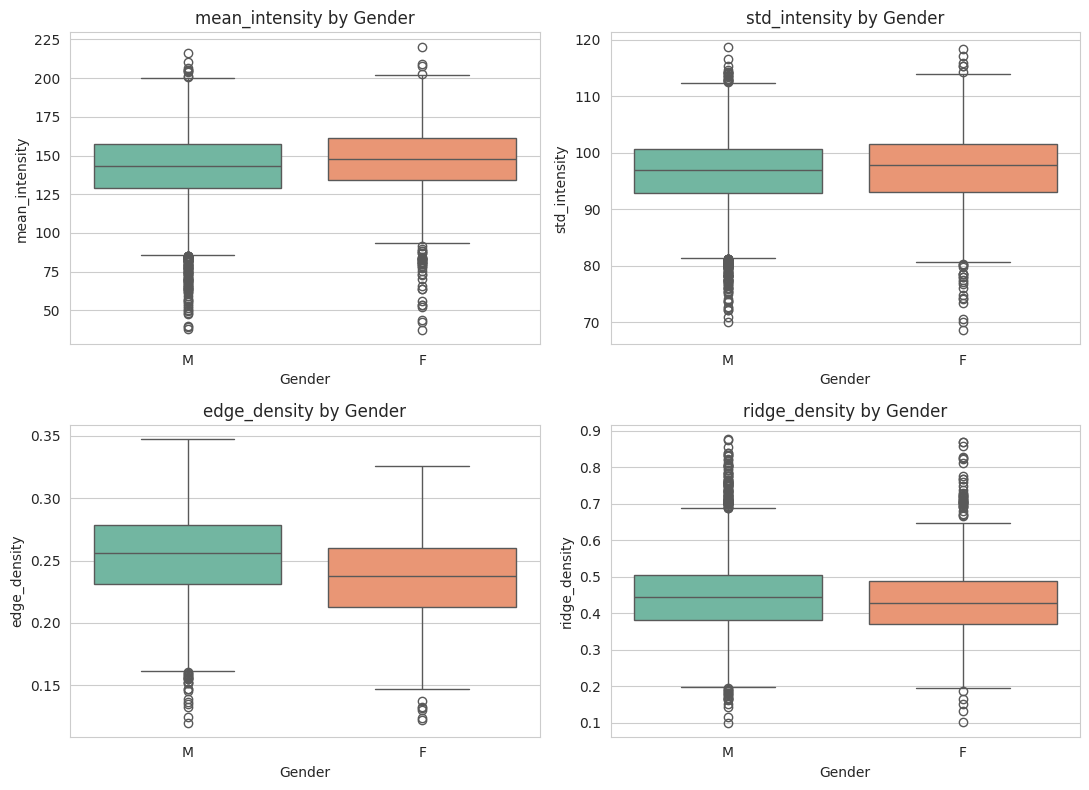

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(data=df, x="gender", y=col, ax=ax, palette="Set2")
    # same boxplot idea as above, but now drawn separately for each gender side-by-side, so we can compare them directly
    ax.set_title(f"{col} by Gender")
    ax.set_xlabel("Gender")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()


**Interpretation:** if male and female boxes clearly sit at different levels for a feature, that feature is likely useful for classification. If the boxes overlap heavily, that feature probably won't help the model tell the classes apart on its own.

### 12.6 Correlation heatmap

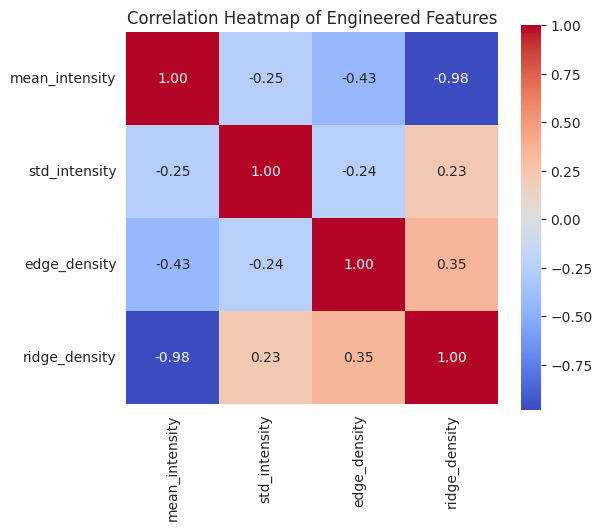

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
# heatmap draws the correlation matrix as a color grid; annot=True writes the actual number in each cell
# cmap="coolwarm" makes strong positive correlations red and strong negative ones blue
# fmt=".2f" rounds the printed numbers to 2 decimal places; square=True keeps each cell perfectly square-shaped

plt.title("Correlation Heatmap of Engineered Features")
plt.show()


**Interpretation:** high correlation (close to 1 or -1) between two features means they carry overlapping information - a candidate for dropping one to reduce redundancy. Values near 0 mean the features are independent and each contributes different information.

### 12.7 Pair plot (selected numeric features, colored by gender)

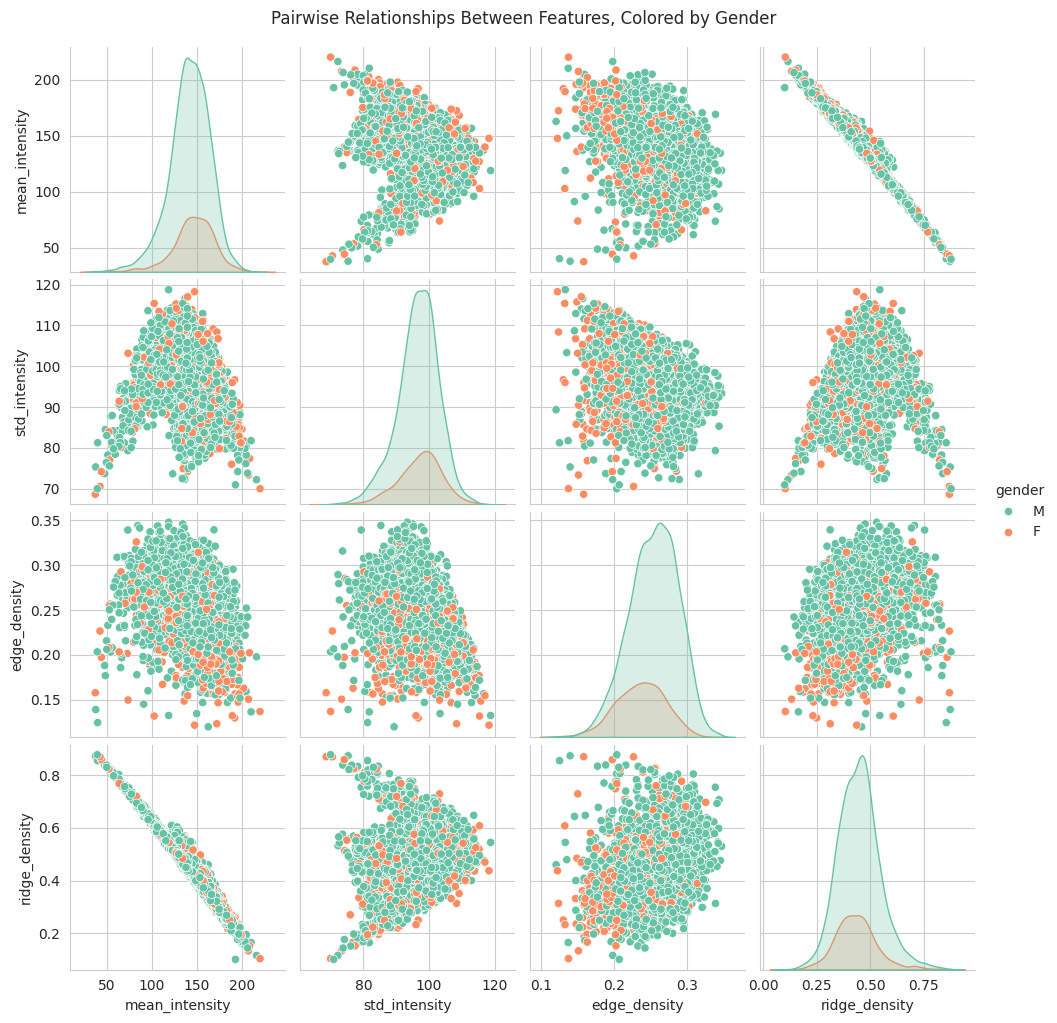

In [ ]:
sns.pairplot(df, vars=numeric_cols, hue="gender", palette="Set2", diag_kind="kde")
# pairplot draws every feature against every other feature as small scatter plots, in one big grid
# hue="gender" colors the points by gender, so we can visually spot separation between classes
# diag_kind="kde" draws a smooth distribution curve (instead of a scatter plot) along the diagonal, where a feature would be plotted against itself

plt.suptitle("Pairwise Relationships Between Features, Colored by Gender", y=1.02)
plt.show()


**Interpretation:** look for pairs of features where male and female points form visibly separate clusters - those pairs are the most useful combinations for classification. Heavy overlap between colors means that pair alone doesn't separate the classes well.

### 12.8 Scatter plot - relationship between two specific features

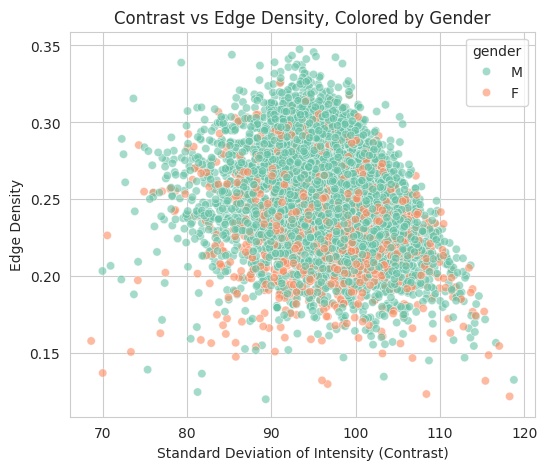

In [ ]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="std_intensity", y="edge_density", hue="gender", palette="Set2", alpha=0.6)
# scatterplot puts one dot per image, positioned by its std_intensity (x) and edge_density (y) values
# hue="gender" colors dots by gender; alpha=0.6 makes dots slightly see-through so overlapping points are visible

plt.title("Contrast vs Edge Density, Colored by Gender")
plt.xlabel("Standard Deviation of Intensity (Contrast)")
plt.ylabel("Edge Density")
plt.show()


**Interpretation:** this checks whether contrast and edge density together help separate male vs female fingerprints. If the two color groups form distinguishable regions, this feature pair has predictive value; if they're mixed together, it doesn't.

### 12.9 Feature importance (Random Forest)

/tmp/ipykernel_969/3653894307.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis")


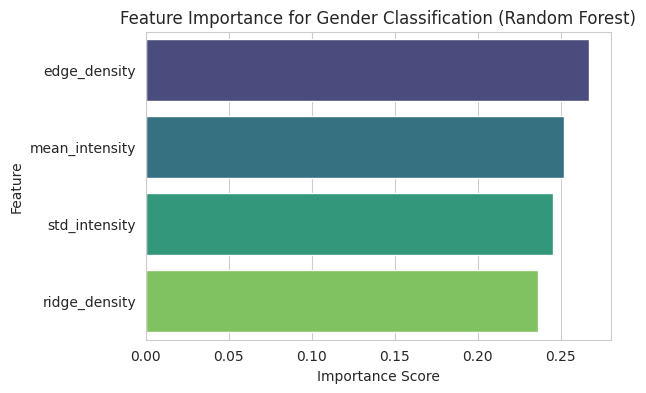

,feature,importance
2,edge_density,0.266864
0,mean_intensity,0.251822
1,std_intensity,0.245114
3,ridge_density,0.236200


In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
# creates a Random Forest model made of 200 individual decision trees; random_state=42 makes results reproducible

rf.fit(df[numeric_cols], df["gender_encoded"])
# trains the model to predict gender_encoded using our 4 numeric features

importance_df = pd.DataFrame({
    "feature": numeric_cols,
    "importance": rf.feature_importances_
    # feature_importances_ tells us how much each feature contributed to the trees' decisions, on average
}).sort_values("importance", ascending=False)   # sort from most important to least important

plt.figure(figsize=(6, 4))
sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis")
plt.title("Feature Importance for Gender Classification (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

importance_df


**Interpretation:** the feature at the top contributes the most to the Random Forest's ability to distinguish male vs female fingerprints. This complements the mutual information and F-test scores from the feature selection step - if all three methods agree on the same top feature(s), that's a strong signal they genuinely matter, rather than being an artifact of one particular method.

## Summary

**Milestone 1 - Preprocessing:**

| Step | What we did |
|---|---|
| Dataset | SOCOFing fingerprints (Real folder), ~6,000 images |
| Target | Gender (M/F), pulled from filenames |
| Missing values | Checked - none found |
| Duplicates | Checked - none found |
| Resize | All images resized to 96x96 |
| Scaling | Pixel values scaled from 0-255 to 0-1 |
| Encoding | Gender converted to 0/1 |
| Split | 70% train / 15% validation / 15% test |
| Imbalance | Fixed with SMOTE-Tomek (training set only) |

**Milestone 2 - Feature Engineering & EDA:**

| Step | What we did |
|---|---|
| Feature engineering | Extracted 4 numeric features per image: mean intensity, std intensity, edge density, ridge density |
| Not applicable | Date/time and text feature extraction - dataset has no such fields |
| Feature selection | Correlation matrix, variance threshold, mutual information, SelectKBest (F-test) |
| EDA visualizations | Histograms/KDE, count plots, target distribution, box plots, class-wise comparisons, correlation heatmap, pair plot, scatter plot, feature importance |

Next milestone: model development, using the preprocessed images and/or engineered features from this notebook.
